In [1]:
%pip install scikit-learn matplotlib xgboost

import sys
import os
from pathlib import Path
from io import BytesIO
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

ROOT_DIR = Path("c:\\Users\\rafae\\OneDrive\\Documentos\\F1")
sys.path.insert(0, str(ROOT_DIR))

from pipeline.utils.storage import AzureBlobStorage

AZURE_CONNECTION_STRING = os.getenv("AZURE_STORAGE_CONNECTION_STRING")
GOLD_CONTAINER = "modelready"

storage_gold = AzureBlobStorage(AZURE_CONNECTION_STRING, GOLD_CONTAINER)

container_client = storage_gold.container_client
requested_blob = "sgold_data.parquet"

try:
	available_blobs = [b.name for b in container_client.list_blobs()]
except Exception as e:
	logging.error("Erro ao listar blobs no container: %s", e)
	raise

if requested_blob not in available_blobs:
	logging.warning("Blob '%s' não encontrado no container '%s'. Blobs disponíveis: %s", requested_blob, GOLD_CONTAINER, available_blobs)
	parquet_candidates = [n for n in available_blobs if n.lower().endswith(".parquet")]
	if parquet_candidates:
		chosen_blob = parquet_candidates[0]
		logging.info("Usando blob alternativo encontrado: %s", chosen_blob)
	else:
		raise FileNotFoundError(f"Blob '{requested_blob}' não encontrado e não .parquet no container '{GOLD_CONTAINER}'.")
else:
	chosen_blob = requested_blob

blob_client = container_client.get_blob_client(chosen_blob)
parquet_bytes = blob_client.download_blob().readall()
df = pd.read_parquet(BytesIO(parquet_bytes))

logging.info(f"Parquet carregado Blob: {chosen_blob} Shape: {df.shape}")
df.head()


[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


,position,driver_number,number_of_laps,dnf,dns,dsq,gap_to_leader,duration,session_key,points,...,driver_form_last3,wind_speed_mean_zscore,wind_direction_mean_zscore,rainfall_mean_zscore,track_temperature_mean_zscore,air_temperature_mean_zscore,humidity_mean_zscore,pressure_mean_zscore,target_final_position,target_champion_points
0,1.0,1,57.0,False,False,False,0,5504.742,9472,26.0,...,1.0,-1.260657,-1.773315,-0.372325,-1.231942,-1.052473,-0.317152,0.582254,1.0,763.0
1,6.0,4,57.0,False,False,False,48.458,5553.200,9472,8.0,...,6.0,-1.260657,-1.773315,-0.372325,-1.231942,-1.052473,-0.317152,0.582254,6.0,723.0
2,8.0,81,57.0,False,False,False,56.082,5560.824,9472,4.0,...,8.0,-1.260657,-1.773315,-0.372325,-1.231942,-1.052473,-0.317152,0.582254,8.0,628.0
3,1.0,1,50.0,False,False,False,0,4843.273,9480,25.0,...,1.0,-0.570439,-1.054119,-0.372325,-0.398964,0.463110,0.480960,0.493560,1.0,763.0
4,4.0,81,50.0,False,False,False,32.007,4875.280,9480,12.0,...,6.0,-0.570439,-1.054119,-0.372325,-0.398964,0.463110,0.480960,0.493560,4.0,628.0


In [2]:
print(df.head())
print(df.info())
print(df.describe().T)
print(df.isnull().sum() / len(df) * 100)

   position  driver_number  number_of_laps    dnf    dns    dsq gap_to_leader  \
0       1.0              1            57.0  False  False  False             0   
1       6.0              4            57.0  False  False  False        48.458   
2       8.0             81            57.0  False  False  False        56.082   
3       1.0              1            50.0  False  False  False             0   
4       4.0             81            50.0  False  False  False        32.007   

   duration  session_key  points  ... driver_form_last3  \
0  5504.742         9472    26.0  ...               1.0   
1  5553.200         9472     8.0  ...               6.0   
2  5560.824         9472     4.0  ...               8.0   
3  4843.273         9480    25.0  ...               1.0   
4  4875.280         9480    12.0  ...               6.0   

  wind_speed_mean_zscore wind_direction_mean_zscore rainfall_mean_zscore  \
0              -1.260657                  -1.773315            -0.372325   
1     

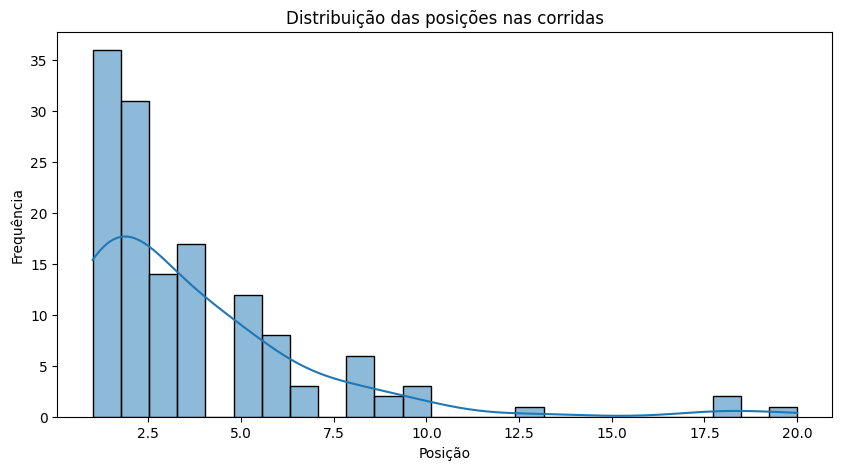

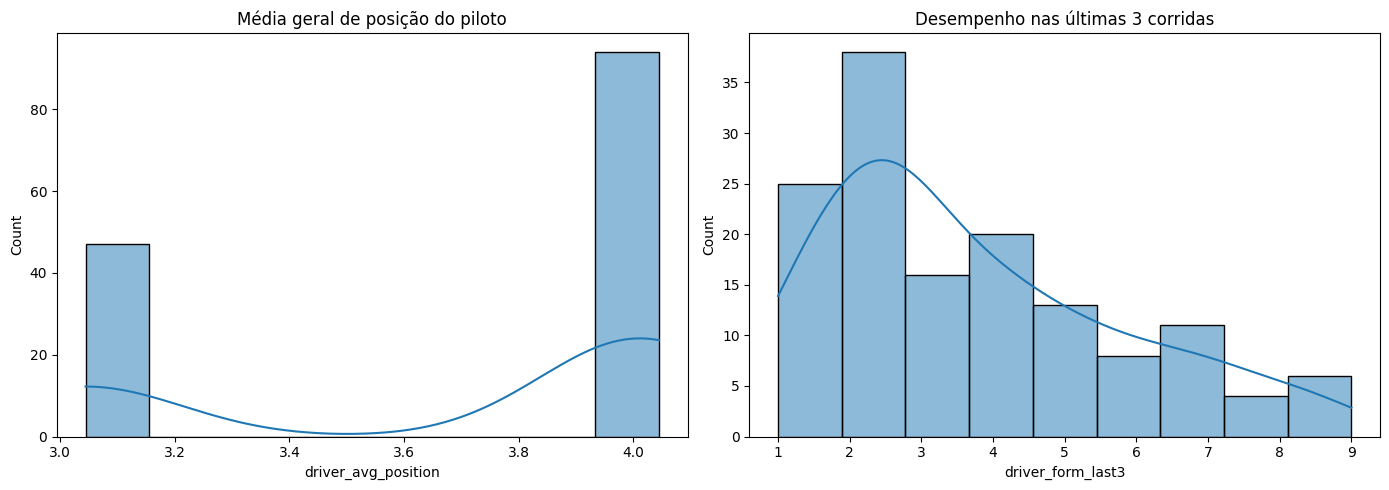

Frequência de abandonos (DNF)
dnf
False    96.45%
True      3.55%
Name: proportion, dtype: object


In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['position'], bins=25, kde=True)
plt.title('Distribuição das posições nas corridas')
plt.xlabel('Posição')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['driver_avg_position'], kde=True)
plt.title('Média geral de posição do piloto')
plt.xlabel('driver_avg_position')

plt.subplot(1, 2, 2)
sns.histplot(df['driver_form_last3'], kde=True)
plt.title('Desempenho nas últimas 3 corridas')
plt.xlabel('driver_form_last3')
plt.tight_layout()
plt.show()

dnf_counts = df['dnf'].value_counts(normalize=True) * 100

print("Frequência de abandonos (DNF)")
print(dnf_counts.round(2).astype(str) + '%')


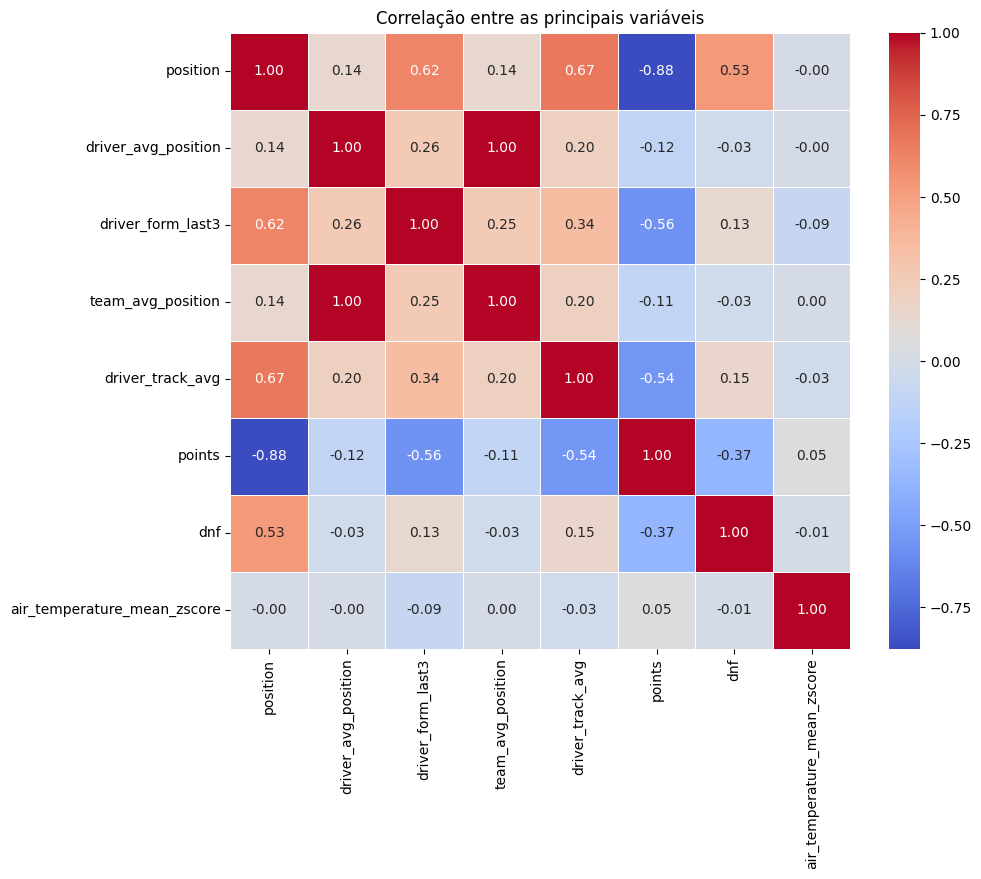

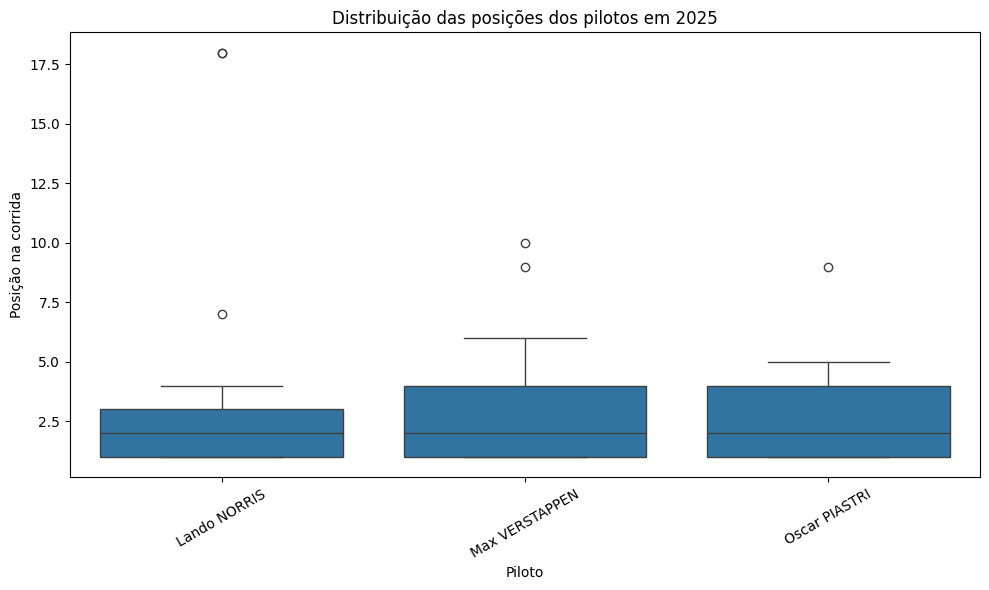

In [4]:
key_cols = ['position', 'driver_avg_position', 'driver_form_last3',
            'team_avg_position', 'driver_track_avg', 'points', 'dnf',
            'air_temperature_mean_zscore']

plt.figure(figsize=(10, 8))
corr_matrix = df[key_cols].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlação entre as principais variáveis')
plt.show()


df_2025 = df[df['year'] == 2025]

plt.figure(figsize=(10, 6))
sns.boxplot(x='full_name', y='position', data=df_2025)
plt.title('Distribuição das posições dos pilotos em 2025')
plt.xlabel('Piloto')
plt.ylabel('Posição na corrida')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



In [5]:
std_avg = (
    df.groupby('full_name')['driver_std_position']
      .mean()
      .sort_values()
)

print("Média do desvio padrão por piloto")
print(std_avg)

Média do desvio padrão por piloto
full_name
Max VERSTAPPEN    2.275917
Oscar PIASTRI     2.875884
Lando NORRIS      4.429643
Name: driver_std_position, dtype: float64


C:\Users\rafae\AppData\Local\Temp\ipykernel_17520\2210233289.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(


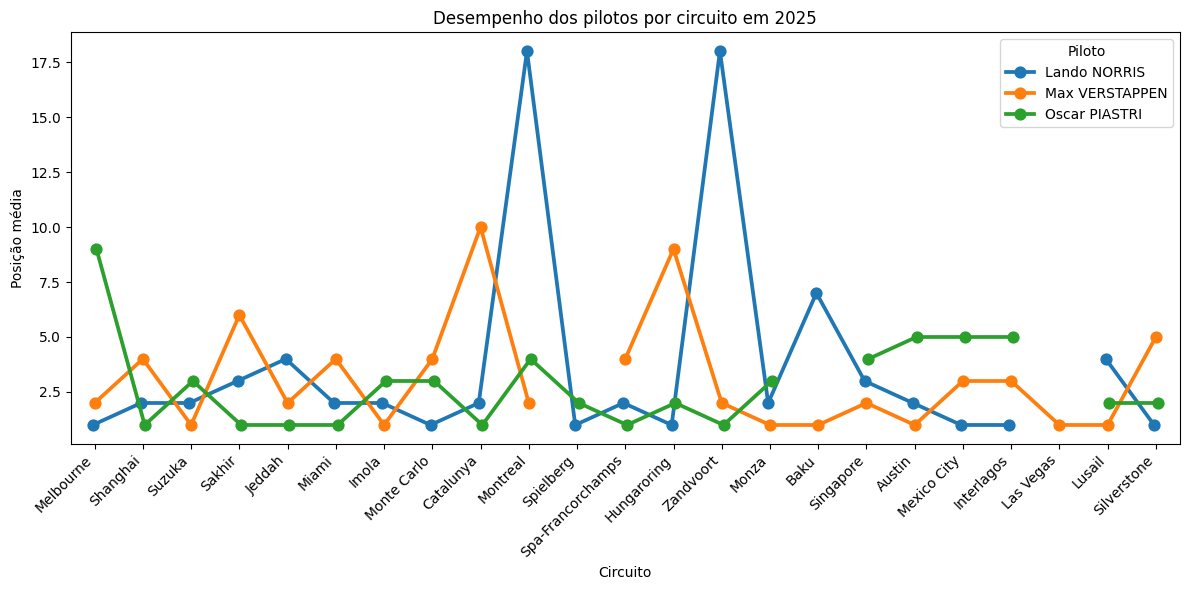

In [6]:
plt.figure(figsize=(12, 6))
sns.pointplot(
    data=df_2025,
    x='circuit_short_name',
    y='position',
    hue='full_name',
    dodge=True,
    ci=None
)
plt.title('Desempenho dos pilotos por circuito em 2025')
plt.xlabel('Circuito')
plt.ylabel('Posição média')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Piloto')

plt.tight_layout()
plt.show()


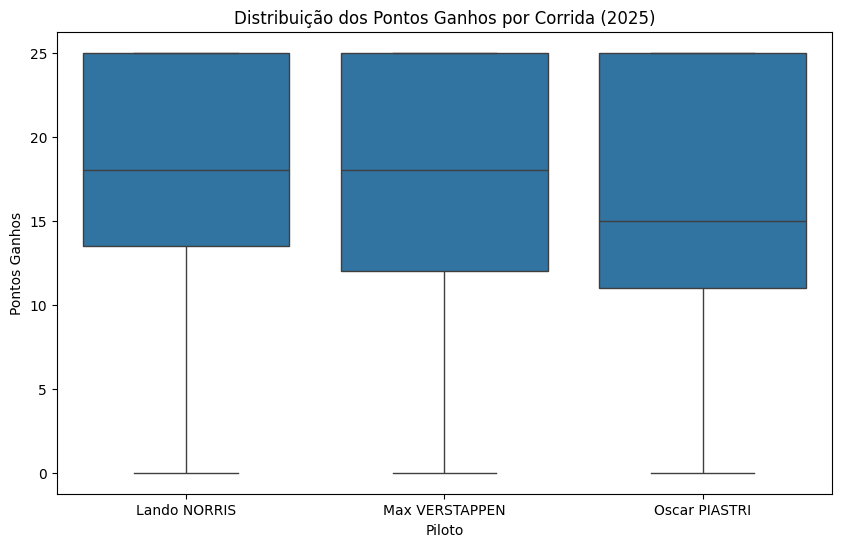

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='full_name', y='points', data=df_2025)
plt.title('Distribuição dos Pontos Ganhos por Corrida (2025)')
plt.ylabel('Pontos Ganhos')
plt.xlabel('Piloto')
plt.show()

In [8]:
df_modeling = df.copy()

# Convertando numericos que vieram como string
numerical_to_convert = ['gap_to_leader', 'duration']
for col in numerical_to_convert:
    df_modeling[col] = pd.to_numeric(df_modeling[col], errors='coerce')

    # Se a coluna tem valores válidos, preenche NAs com o dobro do máximo
    if df_modeling[col].notna().any() and df_modeling[col].max() > 0:
        df_modeling[col].fillna(df_modeling[col].max() * 2, inplace=True)
    else:
        df_modeling[col].fillna(0, inplace=True)

numerical_features = [
    'driver_avg_position', 'driver_std_position', 'team_avg_position', 
    'team_std_position', 'track_avg_position', 'track_std_position',
    'driver_track_avg', 'driver_form_last3', 
    'wind_speed_mean_zscore', 'wind_direction_mean_zscore', 
    'rainfall_mean_zscore', 'track_temperature_mean_zscore', 
    'air_temperature_mean_zscore', 'humidity_mean_zscore', 
    'pressure_mean_zscore'
]
for col in numerical_features:
    df_modeling[col] = df_modeling[col].fillna(df_modeling[col].mean())

# One-hot encoding das categorias principais
categorical_features = ['full_name', 'team_name', 'circuit_short_name']
df_processed = pd.get_dummies(df_modeling, columns=categorical_features, drop_first=True)

df_clean = df_processed.copy()
df_clean.dropna(subset=['position'], inplace=True)
df_clean['position'] = df_clean['position'].astype(int)
y = df_clean['position']

# Removo colunas que não vou usar
cols_to_drop = [
    'position', 'target_final_position', 'target_champion_points',
    'driver_number', 'year', 'location', 'country_name', 'country_code_x',
    'session_key', 'lap_number', 'category', 'flag', 'day', 
    'name_acronym', 'country_code_y', 'race_index'
]
X = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])

# Apenas numericos sem duplicados
X = X.select_dtypes(exclude=['object'])
X = X.loc[:, ~X.columns.duplicated()]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_cols = X_train.columns.unique()


C:\Users\rafae\AppData\Local\Temp\ipykernel_17520\3305064476.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_modeling[col].fillna(df_modeling[col].max() * 2, inplace=True)


In [9]:
# Treinamento do modelo
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    tree_method='hist'
)
xgb_model.fit(X_train, y_train)

# Predição e pos-processamento basico
y_pred = xgb_model.predict(X_test)
y_pred_rounded = np.round(y_pred).astype(int)
y_pred_rounded = np.clip(y_pred_rounded, 1, 20)

# Métricas de avaliação
print(f"MAE: {mean_absolute_error(y_test, y_pred_rounded):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")


MAE: 0.50
R²: 0.76


In [10]:
# Cálculo dos pontos atuais
contenders = df['full_name'].unique()
df_contenders = df[df['full_name'].isin(contenders)].copy()

df_2025 = df_contenders[df_contenders['year'] == 2025].copy()
points_sum = df_2025.groupby('full_name')['points'].sum().reset_index()
current_points = dict(zip(points_sum['full_name'], points_sum['points']))

print("Pontos Atuais")
print(current_points)

# Base da simulação da corrida final
final_race_df = (
    df_2025[df_2025['full_name'].isin(contenders)][['full_name', 'team_name']]
    .drop_duplicates()
    .copy()
)
final_race_df['circuit_short_name'] = 'Abu Dhabi'

# Features históricas
driver_avg = df_contenders.groupby('full_name')['position'].mean().reset_index()
driver_avg = driver_avg.rename(columns={'position': 'driver_avg_position'})
final_race_df = final_race_df.merge(driver_avg, on='full_name', how='left')

df_abu = df_contenders[df_contenders['circuit_short_name'] == 'Abu Dhabi']
driver_track_avg = df_abu.groupby('full_name')['position'].mean().reset_index()
driver_track_avg = driver_track_avg.rename(columns={'position': 'driver_track_avg'})
final_race_df = final_race_df.merge(driver_track_avg, on='full_name', how='left')

last_race_index = df_2025['race_index'].max()
df_last3 = df_2025[df_2025['race_index'] > (last_race_index - 3)]
driver_form_last3 = (
    df_last3.groupby('full_name')['position']
    .mean()
    .reset_index()
    .rename(columns={'position': 'driver_form_last3'})
)
final_race_df = final_race_df.merge(driver_form_last3, on='full_name', how='left')

team_avg = df.groupby('team_name')['position'].mean().reset_index()
team_avg = team_avg.rename(columns={'position': 'team_avg_position'})
final_race_df = final_race_df.merge(team_avg, on='team_name', how='left')

# Preenche features numéricas ausentes com a media do treino
categorical_features = ['full_name', 'team_name', 'circuit_short_name']

for col in train_cols:
    if col not in final_race_df.columns and not any(f in col for f in categorical_features):
        final_race_df[col] = X_train[col].mean()

final_race_df['dnf'] = 0
final_race_df['gap_to_leader'] = X_train.get('gap_to_leader', pd.Series([0])).mean()
final_race_df['duration'] = X_train.get('duration', pd.Series([0])).mean()

# Preenche numéricos restantes
for col in final_race_df.select_dtypes(include=np.number).columns:
    final_race_df[col] = final_race_df[col].fillna(final_race_df[col].mean())

# One-hot e alinhamento de colunas
df_final_processed = pd.get_dummies(final_race_df, columns=categorical_features, drop_first=True)
df_final_processed = df_final_processed.reindex(columns=train_cols, fill_value=0)

# Predição continua
final_preds = xgb_model.predict(df_final_processed)

final_race_df['predicted_score'] = final_preds
final_race_df = final_race_df.sort_values('predicted_score')

# Ranking final
final_race_df['final_race_rank'] = np.arange(1, len(final_race_df) + 1)

df_final_race_output = final_race_df[['full_name', 'final_race_rank', 'predicted_score']]
print("\n-Posições Previstas")
print(df_final_race_output)

# Cálculo de pontos da corrida final
def position_to_points(pos):
    points_map = {1: 25, 2: 18, 3: 15, 4: 12, 5: 10, 6: 8, 7: 6, 8: 4, 9: 2, 10: 1}
    return points_map.get(pos, 0)

df_championship = final_race_df.copy()
df_championship.rename(columns={'final_race_rank': 'predicted_position'}, inplace=True)

df_championship['points_final_race'] = df_championship['predicted_position'].apply(position_to_points)
df_championship['current_points'] = df_championship['full_name'].map(current_points)
df_championship['total_points_2025'] = (
    df_championship['current_points'] + df_championship['points_final_race']
)

champion = df_championship.sort_values('total_points_2025', ascending=False).iloc[0]

print("\nResultado Final")
print(df_championship[['full_name', 'current_points', 'points_final_race', 'total_points_2025']])
print(f"\nCampeão previsto: {champion['full_name']} com {champion['total_points_2025']} pontos")


Pontos Atuais
{'Lando NORRIS': 379.0, 'Max VERSTAPPEN': 364.0, 'Oscar PIASTRI': 363.0}

-Posições Previstas
        full_name  final_race_rank  predicted_score
0    Lando NORRIS                1         2.999987
1  Max VERSTAPPEN                2         2.999987
2   Oscar PIASTRI                3         2.999987

Resultado Final
        full_name  current_points  points_final_race  total_points_2025
0    Lando NORRIS           379.0                 25              404.0
1  Max VERSTAPPEN           364.0                 18              382.0
2   Oscar PIASTRI           363.0                 15              378.0

Campeão previsto: Lando NORRIS com 404.0 pontos



Top 10 features mais importantes
                  Feature  Importance
                   points    8.578578
                      dnf    3.666633
            gap_to_leader    0.760005
      driver_std_position    0.014292
       track_std_position    0.003601
           number_of_laps    0.001406
   track_temperature_mean    0.000620
        driver_form_last3    0.000002
circuit_short_name_Lusail    0.000001


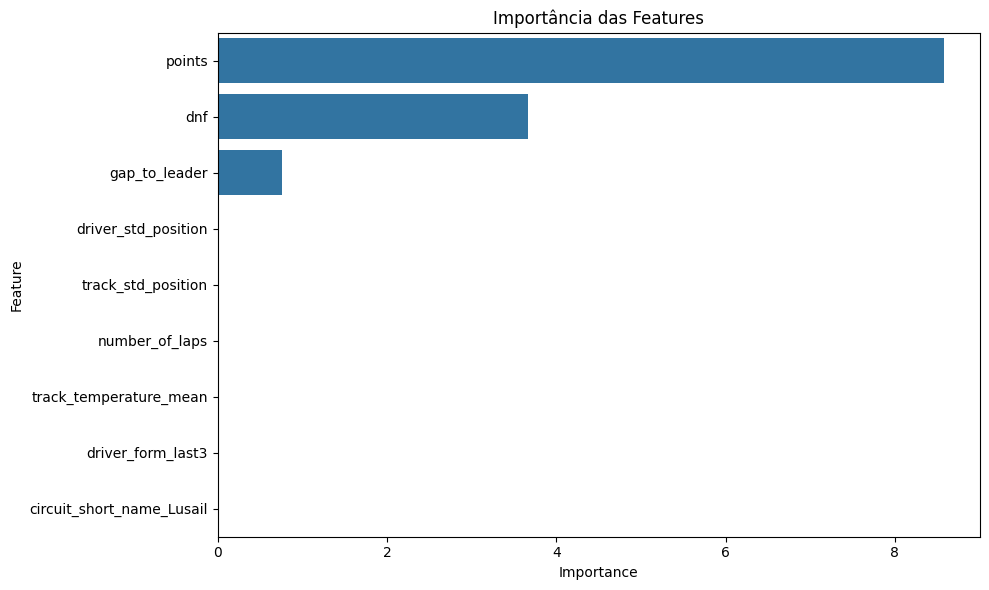

In [11]:
# Importância das features
importance = xgb_model.get_booster().get_score(importance_type="gain")

importance_df = (
    pd.DataFrame(importance.items(), columns=["Feature", "Importance"])
    .sort_values("Importance", ascending=False)
)

print("\nTop 10 features mais importantes")
print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Importância das Features")
plt.tight_layout()
plt.show()